In [1]:
import ROOT
import numpy as np
import math
import pandas as pd
import fastjet
import matplotlib.pyplot as plt


In [2]:
#from preliminary file

f = ROOT.TFile.Open("/Users/rohanjagadeesan/Desktop/Code/li_lab/WinnerTakeAll/parton_data.root")
tree = f.Get("trackTree") 

jet_radius = 0.8 #max accepted by fastjet is 1000. radius value in prl paper is 0.8 in lab frame

wta_def = fastjet.JetDefinition(fastjet.antikt_algorithm, jet_radius, fastjet.WTA_pt_scheme) #wta definition
std_def = fastjet.JetDefinition(fastjet.antikt_algorithm, jet_radius) #standard E scheme definition

In [3]:
#modified from Xiao's code
#clarify what the criteria is - he had something about 200 that i have not included


def eventPass(jetPt, jetEta):  
    '''
    criteria for jet selection
    
    inputs:
        - jetEta: the jet's pseudorapidity, a positive or negative float
        - jetPt: the jet's momentum in GeV, a positive float             !!! USING STANDARD PT FOR CRITERIA, maybe later can try out with wta pt selection

    output: true if passed, false otherwise
    '''
    jetEtaCut = 1.6 #from PRL paper page 2
    jetPtCut = 550 #from prl paper,         STANDARD pt, not WTA

    if(abs(jetEta)>jetEtaCut): return False
    if(jetPt < jetPtCut): return False

    return True


def particlePass(particlePt, particleEta, particleCharge):
    '''
    criteria for particle selection

    inputs: 
        - particlePt: positive float for particle momentum magnitude
        - particleEta: float (positive or negative) for particle pseudorapidity
        - particleCharge: the particle's charge, not sure about the variable type

    output: true if passed, false otherwise
    '''
    particlePtCut = 0.3 #from prl paper page 2
    particleEtaCut = 2.4 #from prl paper page 2
    
    if(particlePt < particlePtCut): return False
    if(abs(particleEta) > particleEtaCut): return False

    if (particleCharge is None or particleCharge==0): return False #only accepting charged particles

    return True



In [ ]:
#from prelim file

def make_pseudojets(pts, etas, phis, charges):
    '''
    converts particles of one jet to a list of pseudojets. particle quality cuts are built in.
    inputs:
        - pts: a vector of particles for a given jet
        - etas: the corresponding pseudorapidities for each particle in the jet
        - phis: the corresponding azimuthal angles for each particle in the jet
        - charges: the charges of each particle in the jet
        
    output:
        - pj_list: a list of pseudojets, each pseudojet represents a particle in the jet
    '''
    
    pj_list = []

    for i in range(len(pts)): #looping through each particle in the jet
        
        if particlePass(pts[i], etas[i], charges[i]): #particle selection criteria
            p = fastjet.PseudoJet() #initialising a pseudojet
            p.reset_PtYPhiM(pts[i], etas[i], phis[i], 0.0) #defining the i-th particle as a pseudojet - is mass=0 fine?
            pj_list.append(p) #adding the particle to the list of pseudojets
    
    return pj_list #list of pseudojets


In [5]:
#transforming values to jet frame


def particleToJetFrame(jet_px, jet_py, jet_pz, particle):
    """
    Transforms one constituent particle to the jet frame. eta_star quality cuts reflected in 'include' boolean.
    
    Inputs:
        - jet_px, jet_py, jet_pz: The lab frame cartesian momentum 3-vector for the WHOLE jet
        - particle: A lab frame pseudoJet CONSTITUENT of that jet

    output:
        - jt: jet frame transverse momentum of the particle
        - eta_star: jet frame pseudorapidity of the particle
        - phi_star: jet frame phi of the particle
        - include: true if particle meets criteria, false otherwise
        - winner: true for winner in WTA frame, false otherwise
    """

    # 1. Convert to ROOT TVector3
    # Use px, py, pz to ensure we have the full 3D vector
    p_jet = ROOT.TVector3(jet_px, jet_py, jet_pz)                 #momentum 3-vector of the whole jet
    p_part = ROOT.TVector3(particle.px(), particle.py(), particle.pz()) #momentum 3-vector of the particle

    # 1. Calculate Eta star (Relative Eta), discard non-qualifiers
    theta = p_part.Angle(p_jet)     #dot product angle between particle and jet momenta, range 0 to pi
    #cases for theta
    if theta == 0: #winner particle in WTA
        return 0, 0, 0, True, True #include and winner are true
    elif theta == math.pi: #on -z axis
        return 0, 0, 0, False, False #include is false because this particle doesn't qualify due to being on the z axis
    else: 
        eta_star = -math.log(math.tan(theta / 2.0)) #pseudorapidity formula for acceptable theta
        if abs(eta_star) > 5:
            return 0, 0, 0, False, False #include is false because absolute eta_star greater than 5 not allowed
        #what about eta_star less than 0.86? that is the anti-kt jet bdry. do i need to exclude stuff outside that?

    # 2. Calculate jT (Relative pT)
    jt = p_part.Perp(p_jet) #magnitude of part of particle momentum that is perpendicular to jet momentum
    if jt < 0.3 or jt > 3: #keeping 0.3geV<jt<3GeV . Maybe not a necessary cut?
        return 0, 0, 0, False, False #include is false for these jt criteria

    # 4. Calculate Phi star (Relative Phi)
    unit_jet = p_jet.Unit()
    z_axis = ROOT.TVector3(0, 0, 1)
    
    # Vector purely transverse to the jet axis
    v_pt = p_part - (unit_jet * p_part.Dot(unit_jet)) #magnitude of this is jt
    
    # Define the reference plane (jet axis & beam line)
    phi_origin = unit_jet.Cross(unit_jet.Cross(z_axis)) #phi = 0 vector, taken from Xiao's code
    phi_star = v_pt.Angle(phi_origin)
    
    # Determine the sign of phi_star
    if (phi_origin.Cross(v_pt.Unit())).Dot(unit_jet) < 0:
        phi_star = -phi_star


    return jt, eta_star, phi_star, True, False #if we reached this point without returning, then include should be true and winner false


def jetToJetFrame(labFrame_pj):
    '''
    transforms all constituents of a full jet from lab frame to the jet frame

    input: lab_pj, a jet pseudojet with coordinates measured in lab frame. The jet should already be clustered according to the desired scheme.

    output: ple_pj_list, a list of valid particle pseudojets with coordinates measured in the jet frame. 
    '''
    #Extracting px, py, pz of the whole jet in lab frame
    jet_px =  labFrame_pj.px()
    jet_py = labFrame_pj.py()
    jet_pz = labFrame_pj.pz()
    
    ple_pj_list = [] #initialising list of particle pseudojets

    #looping through constituents
    jet_constituents = labFrame_pj.constituents()
    for particle in jet_constituents:
        
        #finding jet frame coordinates for the particle
        jetFrame_pt, jetFrame_eta, jetFrame_phi, include, winner = particleToJetFrame(jet_px, jet_py, jet_pz, particle)

        if include == True: #particle meets eta_star criteria
            p_in_jet = fastjet.PseudoJet() #initialising a pseudojet
            
            if winner: #special case for winner particle
                p_in_jet.reset(0, 0, particle.modp(), particle.E()) 
            else: #regular particles
                p_in_jet.reset_PtYPhiM(jetFrame_pt, jetFrame_eta, jetFrame_phi, 0.0) #redefining the particle in the jet frame (last index is mass)
                ple_pj_list.append(p_in_jet) #add the newly defined particle pseudojet to the list

    return ple_pj_list


In [15]:
def mult_bin_check(jet_mult, mult_bin):
    '''
    checks if the jet falls within the given multiplicity bin
    input:
        - jet_mult: jet multiplicity, an integer
        - mult_bin: a list of 1 or 2 integers. 1st is lower bound, and 2nd (if given) is upper bound.
    output: True if between upper and lower bounds. If no upper bound is given, true if jet_mult is above lower bound.
    '''
    if jet_mult>=mult_bin[0]: #checking lower bound
        if len(mult_bin) == 2:  #checking if upper bound given
            return jet_mult<mult_bin[1] #true for between upper and lower bound
        else:
            return True #true for above lower bound, only one index
    return False #if below lower bound

In [12]:
# do the 2 particle correlation
#simplified version rn for testing
def build2pc(pj_list, mult_bin, index=None):
    '''
    builds the 2 particle correlator 
    
    input: 
        - pj_list, a list of particle pseudojets for one jet. these should be in the jet frame
        - index - a tuple (event index, jet index)
        - mult_bin: [lower bound, optional upper bound] the multiplicity bin we want to be within
    
    output:
        info_list, a list of correlator info dictionaries
    '''
    info_list = [] #initialise the list

    multiplicity = len(pj_list) 
    if not mult_bin_check(multiplicity, mult_bin):
        return info_list #returning an empty list if jet is not in the multiplicity bin

    #doing the 2pc since multiplicity bin is satisfied
    for i in range(multiplicity - 1):
        for j in range(i+1, multiplicity): 
            delta_eta_star = pj_list[i].eta() - pj_list[j].eta()
            delta_phi_star = pj_list[i].phi() - pj_list[j].phi()
            dR = math.sqrt(delta_eta_star**2 + delta_phi_star**2)
            
            info_for_2pc = {
                    "dEta": abs(delta_eta_star),
                    "dPhi": abs(delta_phi_star),
                    "dR": dR,
                    "multiplicity": multiplicity #, #number of valid charged particles in the jet
                    #"jet index": index
                    #add pair energy and jet energy later for EEC
                }
            
            info_list.append(info_for_2pc)
    return info_list

In [39]:
#MAIN ANALYSIS CELL

wta_correlation_data = [] #list of dictionaries
std_correlation_data = []
#mult_bin = [60]
#mult_bin = [40, 60]
#mult_bin = [20, 40]
mult_bin = [0, 20]

#jet_index = (-1,-1) #event num, jet num

#loopcount = 0 #for testing the loop
# main event loop, creating the data for each jet
for event in tree:
    #loopcount+=1 #for testing
    #if loopcount>40000:
    #    break
    
    #jet_index = (jet_index[0]+1, -1)
    # 1. Loop over jets in the event
    for ijet in range(event.genJetPt.size()):
        #jet_index = (jet_index[0], jet_index[1]+1)
        
        #extracting standard pt and eta from ROOT data for cuts
        std_pt = event.genJetPt[ijet]
        std_eta = event.genJetEta[ijet]
        
        if eventPass(std_pt, std_eta): #jet cut using STANDARD pt and eta

            # 2. Get the daughter vectors for ONLY this jet
            dau_pts = event.genDau_pt[ijet]
            dau_etas = event.genDau_eta[ijet]
            dau_phis = event.genDau_phi[ijet]
            dau_charges = event.genDau_chg[ijet]

            # 3. Create PseudoJets for this specific jet
            jet_constituents = make_pseudojets(dau_pts, dau_etas, dau_phis, dau_charges) #particle cuts are built in

            # 4. Cluster with WTA and standard to find the new axis
            wta_clustered = fastjet.ClusterSequence(jet_constituents, wta_def)  #this is a cluster sequence, can't be directly queried for momentum, etc.
            wta_jets_tup = fastjet.sorted_by_pt(wta_clustered.inclusive_jets()) #just one jet but it's a tuple so we need 0th index

            std_clustered = fastjet.ClusterSequence(jet_constituents, std_def)  #cluster sequence again
            std_jets_tup = fastjet.sorted_by_pt(std_clustered.inclusive_jets()) #tuple again
            

            if len(wta_jets_tup) > 0: #preventing indexing errors
                wta_jet = wta_jets_tup[0]   #indexing to get the actual pseudojet we can query
                std_jet = std_jets_tup[0]
                
                # 5. shifting to jet frame
                wta_in_jet_frame = jetToJetFrame(wta_jet) #list of particle pseudojets in the jet frame (cuts built in)
                std_in_jet_frame = jetToJetFrame(std_jet)
                
                # Save all the useful info for this specific jet in a dictionary
                wta_jet_info = build2pc(wta_in_jet_frame, mult_bin) #, jet_index)   #mult bin is checked inside
                std_jet_info = build2pc(std_in_jet_frame, mult_bin) #, jet_index)
                
                # Add to our main list of jets
                wta_correlation_data.extend(wta_jet_info)   #if mult bin not satisfied, then nothing happens here
                std_correlation_data.extend(std_jet_info)


wta_df = pd.DataFrame(wta_correlation_data)
std_df = pd.DataFrame(std_correlation_data)

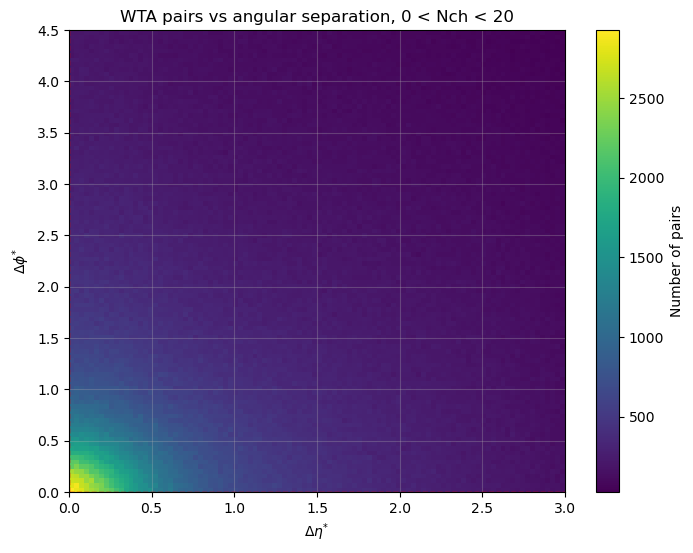

In [40]:
#WTA number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

# 2. Create the 2D Histogram
h = plt.hist2d(wta_df['dEta'], wta_df['dPhi'], 
               bins=(100, 100), 
               range=[[0, 3], [0, 4.5]],                   
               #range=[[-3, 3], [-1, 4.5]], #full 4 quadrants
               cmap='viridis', 
               cmin=1
               )

# 3. Add a colorbar to show what the colors mean (density of jets)
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=1)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=1)

# 5. Labels and styling
if len(mult_bin) == 2:
    title = f"WTA pairs vs angular separation, {mult_bin[0]} < Nch < {mult_bin[1]}"
else: 
    title = f"WTA pairs vs angular separation, {mult_bin[0]} < Nch"


plt.title(title)
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()


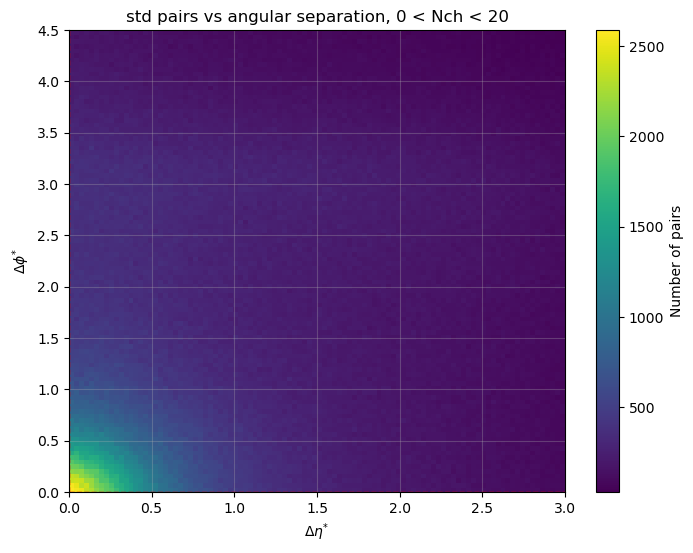

In [41]:
#number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

# 2. Create the 2D Histogram
h = plt.hist2d(std_df['dEta'], std_df['dPhi'], 
               bins=(100, 100), 
               range=[[0, 3], [0, 4.5]],                   
               #range=[[-3, 3], [-1, 4.5]], #full 4 quadrants
               cmap='viridis', 
               cmin=1
               )


# 3. Add a colorbar to show what the colors mean (density of jets)
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=1)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=1)

# 5. Labels and styling
if len(mult_bin) == 2:
    title = f"std pairs vs angular separation, {mult_bin[0]} < Nch < {mult_bin[1]}"
else: 
    title = f"std pairs vs angular separation, {mult_bin[0]} < Nch"

plt.title(title)
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()


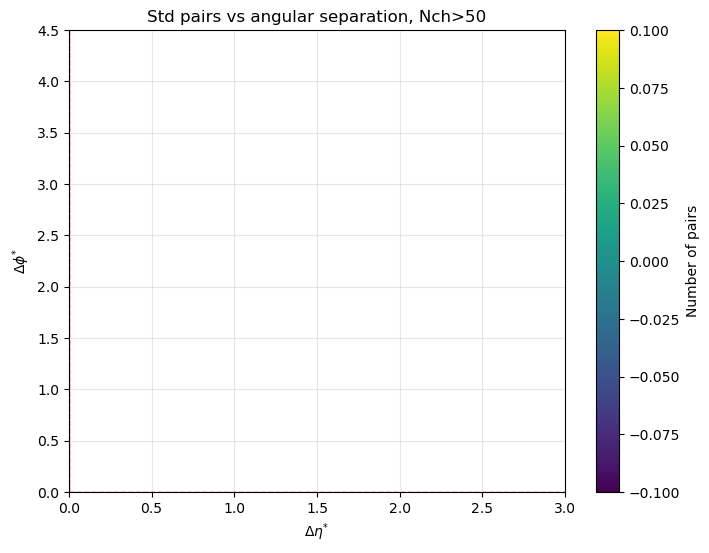

In [42]:
#number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

mult_bin_local = std_df[std_df['multiplicity']>50]

# 2. Create the 2D Histogram
h = plt.hist2d(mult_bin_local['dEta'], mult_bin_local['dPhi'], 
               bins=(100, 100), 
               range=[[0, 3], [0, 4.5]],                   
               #range=[[-3, 3], [-1, 4.5]], #full 4 quadrants
               cmap='viridis', 
               cmin=1
               )

# 3. Add a colorbar to show what the colors mean (density of jets)
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=1)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=1)

# 5. Labels and styling
plt.title('Std pairs vs angular separation, Nch>50')
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()

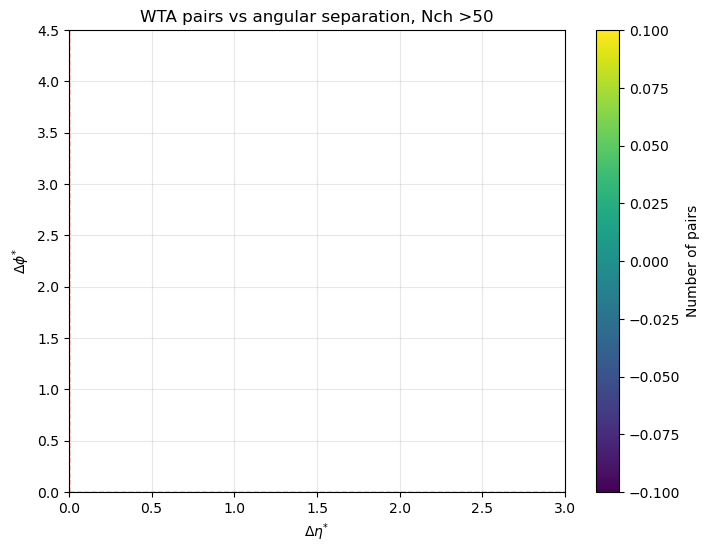

In [43]:
#number of pairs vs dEta and dPhi

plt.figure(figsize=(8, 6))

mult_bin_local = wta_df[wta_df['multiplicity']>50]

# 2. Create the 2D Histogram
h = plt.hist2d(mult_bin_local['dEta'], mult_bin_local['dPhi'], 
               bins=(100, 100), 
               range=[[0, 3], [0, 4.5]],                   
               #range=[[-3, 3], [-1, 4.5]], #full 4 quadrants             
               cmap='viridis', 
               cmin=1
               )

# 3. Add a colorbar to show what the colors mean 
plt.colorbar(h[3], label='Number of pairs')

# 4. Add a horizontal reference line
plt.axhline(0.0, color='red', linestyle='dashed', linewidth=1)
plt.axvline(0.0, color='red', linestyle='dashed', linewidth=1)

# 5. Labels and styling
plt.title(r'WTA pairs vs angular separation, Nch >50')
plt.xlabel(r'$\Delta \eta ^{*}$')
plt.ylabel(r'$\Delta \phi ^{*}$')
plt.grid(True, alpha=0.3)

plt.show()

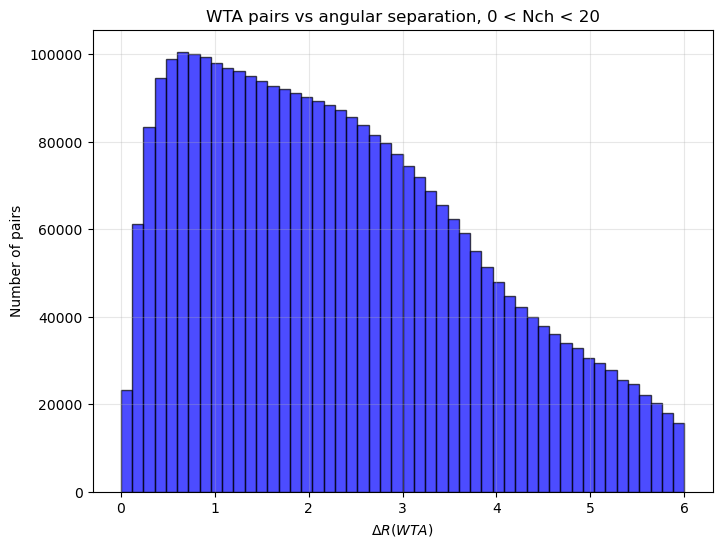

In [44]:
#number of pairs for a given dR

plt.figure(figsize=(8, 6))

# Plot a histogram of the dR column
plt.hist(wta_df['dR'], bins=50, range=(0, 6), color='blue', alpha=0.7, edgecolor='black') #standard jet radius is 0.5

if len(mult_bin) == 2:
    title = f"WTA pairs vs angular separation, {mult_bin[0]} < Nch < {mult_bin[1]}"
else: 
    title = f"WTA pairs vs angular separation, {mult_bin[0]} < Nch"

plt.title(title)
plt.xlabel(r'$\Delta R(WTA)$')
plt.ylabel('Number of pairs')
#plt.yscale('log') # Log scale is standard for this distribution
plt.grid(True, alpha=0.3)
plt.show()

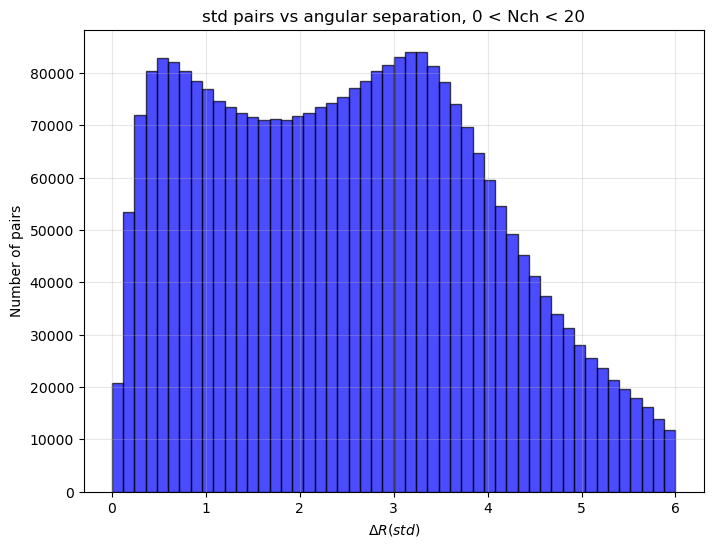

In [45]:
#number of pairs for a given dR

plt.figure(figsize=(8, 6))

# Plot a histogram of the dR column
plt.hist(std_df['dR'], bins=50, range=(0, 6), color='blue', alpha=0.7, edgecolor='black') #standard jet radius is 0.5

if len(mult_bin) == 2:
    title = f"std pairs vs angular separation, {mult_bin[0]} < Nch < {mult_bin[1]}"
else: 
    title = f"std pairs vs angular separation, {mult_bin[0]} < Nch"
plt.title(title)
plt.xlabel(r'$\Delta R(std)$')
plt.ylabel('Number of pairs')
#plt.yscale('log') # Log scale is standard for this distribution
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
print(wta_df)

             dEta      dPhi        dR  multiplicity
0        0.155448  2.530552  2.535322             8
1        1.559537  5.348361  5.571097             8
2        2.019676  0.515985  2.084546             8
3        2.108527  1.293910  2.473881             8
4        2.491859  0.428635  2.528456             8
...           ...       ...       ...           ...
3247802  0.883004  1.988234  2.175493            11
3247803  2.646714  1.620837  3.103580            11
3247804  0.744569  3.098618  3.186819            11
3247805  2.508279  3.466015  4.278402            11
3247806  1.763710  0.367397  1.801569            11

[3247807 rows x 4 columns]
